# Notebook 4 — Discord Analysis

**Discord** measures edge-by-edge discrepancy: how far a 0-cochain is from
being a global section (consistent across all edges).

Two diagnostic views for each edge:

- **Predicted-vs-actual scatter** — Weight edges: $(Wa + b)_j$ vs $z_j$
  (should lie on identity line). ReLU edges: $z_j$ vs $a_j$ (should lie
  on ReLU curve).
- **Residual scatter** — Discord values (predicted $-$ actual) for each
  coordinate.

For the **sheaf method**, the training stalk state is used directly —
stalks evolve via joint dynamics and generally deviate from exact
constraint satisfaction.

For **SGD**, a simple forward pass gives zero discord by construction
(each layer's output is defined as the input to the next). To diagnose
error structure, we embed the SGD weights in a NeuralSheaf, hard-pin
the output to the true labels, and run heat diffusion to convergence.
The resulting state reveals where in the network the prediction error
concentrates.

Hyperparameters match Notebook 2 ($\beta = 1/n$, $dt = 0.005$).

---
## 1. Setup

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from neural_sheaf.sheaf import NeuralSheaf
from neural_sheaf.tasks import (
    TASK_CONFIGS,
    compute_levels,
    train_sheaf_full,
    train_sgd_full,
)
from neural_sheaf.discord import (
    compute_training_discord,
    compute_mean_deviation,
    compute_pinned_discord,
    plotly_pva,
    plotly_residuals,
)
from neural_sheaf.losses import mse_loss, cross_entropy_loss
from neural_sheaf.visualization import (
    plot_discord_pva,
    plot_discord_residuals,
    plot_discord_summary,
)

torch.set_default_dtype(torch.float64)
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 10,
    'axes.titlesize': 11,
})

### Configuration

In [2]:
TASK = 'paraboloid'          # 'paraboloid', 'saddle', 'circular', 'blobs'
N_SPECTRAL_SAMPLES = 50
SPECTRAL_FREQ = 10_000
SEED_WEIGHTS = 0
SEED_STALKS = 42
ENABLE_TENSION = True        # Run tension correction analysis

cfg = TASK_CONFIGS[TASK]
arch = cfg['default_arch']
n_steps = cfg['default_n_steps']
dt = cfg['default_dt']
n_train = cfg['n_train']
beta = 1.0 / n_train
output_activation = cfg['output_activation']
sgd_lr = cfg['sgd_lr']
init_method = cfg.get('init_method', 'random')

print(f"Task: {TASK}")
print(f"Architecture: {arch}")
print(f"β = 1/{n_train} = {beta:.6f}, dt = {dt}")
print(f"SGD lr = {sgd_lr}, n_steps = {n_steps}")


Task: paraboloid
Architecture: [2, 30, 1]
β = 1/300 = 0.003333, dt = 0.005
SGD lr = 0.005, n_steps = 100000


In [3]:
X_tr, Y_tr, X_te, Y_te = cfg['data_fn']()
X_sub = X_tr[:, :N_SPECTRAL_SAMPLES]

levels, level_tags = compute_levels(n_steps)
snapshot_steps = [s for _, s, _ in levels]
level_labels = [f"{l} ({t})" for (l, _, _), t in zip(levels, level_tags)]
level_colors = [c for _, _, c in levels]

print(f"Data: X_tr {X_tr.shape}, Y_tr {Y_tr.shape}")
print(f"Levels: {list(zip(level_labels, snapshot_steps))}")

Data: X_tr torch.Size([2, 300]), Y_tr torch.Size([1, 300])
Levels: [('Poorly trained (1k)', 1000), ('Intermediate (20k)', 20000), ('Well trained (100k)', 100000)]


---
## 2. Train Both Methods

In [4]:
print("Training sheaf (with stalk snapshots)...")
sheaf_history, sheaf_snapshots = train_sheaf_full(
    arch, X_tr, Y_tr, X_te, Y_te, n_steps, beta, dt,
    output_activation, snapshot_steps, SPECTRAL_FREQ, X_sub,
    seed_w=SEED_WEIGHTS, seed_s=SEED_STALKS,
    init_method=init_method)

print("\nTraining SGD...")
sgd_history, sgd_snapshots = train_sgd_full(
    arch, X_tr, Y_tr, X_te, Y_te, n_steps,
    output_activation, sgd_lr, snapshot_steps, SPECTRAL_FREQ, X_sub,
    seed=SEED_WEIGHTS)

sheaf_models = {tag: sheaf_snapshots[s]
                for (_, s, _), tag in zip(levels, level_tags)}
sgd_models = {tag: sgd_snapshots[s]
              for (_, s, _), tag in zip(levels, level_tags)}


Training sheaf (with stalk snapshots)...
  Step     0 | loss=12.099576  λ₁=0.1911  λ_max=3.58  κ=18.7
  Step  10000 | loss=0.529305  λ₁=0.0511  λ_max=12.75  κ=249.5
  Step  20000 | loss=0.231004  λ₁=0.0415  λ_max=15.64  κ=376.8
  Step  30000 | loss=0.134055  λ₁=0.0378  λ_max=17.22  κ=455.5
  Step  40000 | loss=0.098778  λ₁=0.0359  λ_max=18.19  κ=506.9
  Step  50000 | loss=0.084129  λ₁=0.0346  λ_max=18.84  κ=543.9
  Step  60000 | loss=0.076696  λ₁=0.0338  λ_max=19.31  κ=570.7
  Step  70000 | loss=0.071971  λ₁=0.0332  λ_max=19.68  κ=592.3
  Step  80000 | loss=0.068423  λ₁=0.0327  λ_max=19.98  κ=610.5
  Step  90000 | loss=0.065534  λ₁=0.0323  λ_max=20.24  κ=626.3
  Step 100000 | loss=0.063092  λ₁=0.0324  λ_max=20.47  κ=631.8

Training SGD...
  Step     0 | loss=12.099576  λ₁=0.1911  λ_max=3.58  κ=18.7
  Step  10000 | loss=0.029372  λ₁=0.0934  λ_max=7.80  κ=83.6
  Step  20000 | loss=0.008678  λ₁=0.0731  λ_max=10.43  κ=142.8
  Step  30000 | loss=0.005797  λ₁=0.0673  λ_max=11.42  κ=169.8
  S

---
## 3. Sheaf Training Discord

For each training level, we compute per-edge discord from the sheaf
training stalk state. The stalks evolve via joint dynamics and are
generally not at the forward-pass equilibrium.

### 3a. Per-Edge Training Discord

In [5]:
print("Computing sheaf training discord at each level...")
sheaf_discords = {}

for (label, _, _), tag in zip(levels, level_tags):
    s_sheaf, s_state, s_loss = sheaf_models[tag]
    sd = compute_training_discord(s_sheaf, s_state)
    sheaf_discords[tag] = sd
    print(f"  {label} ({tag}): total discord = {sd['total']:.6e}, "
          f"loss = {s_loss:.6f}")
    for key, val in sorted(sd.items()):
        if key != 'total':
            print(f"    {key}: {val:.6e}")

Computing sheaf training discord at each level...
  Poorly trained (1k): total discord = 3.059036e-01, loss = 1.892455
    activation_1: 1.586770e-01
    weight_1: 1.175869e-01
    weight_2: 2.963975e-02
  Intermediate (20k): total discord = 9.690997e-03, loss = 0.231004
    activation_1: 6.075708e-03
    weight_1: 3.177876e-03
    weight_2: 4.374124e-04
  Well trained (100k): total discord = 2.120255e-03, loss = 0.063092
    activation_1: 1.417299e-03
    weight_1: 6.263408e-04
    weight_2: 7.661507e-05


### 3b. Predicted-vs-Actual and Residual Plots (Sheaf)

Weight edges should cluster along the identity line; ReLU edges along the
ReLU curve.

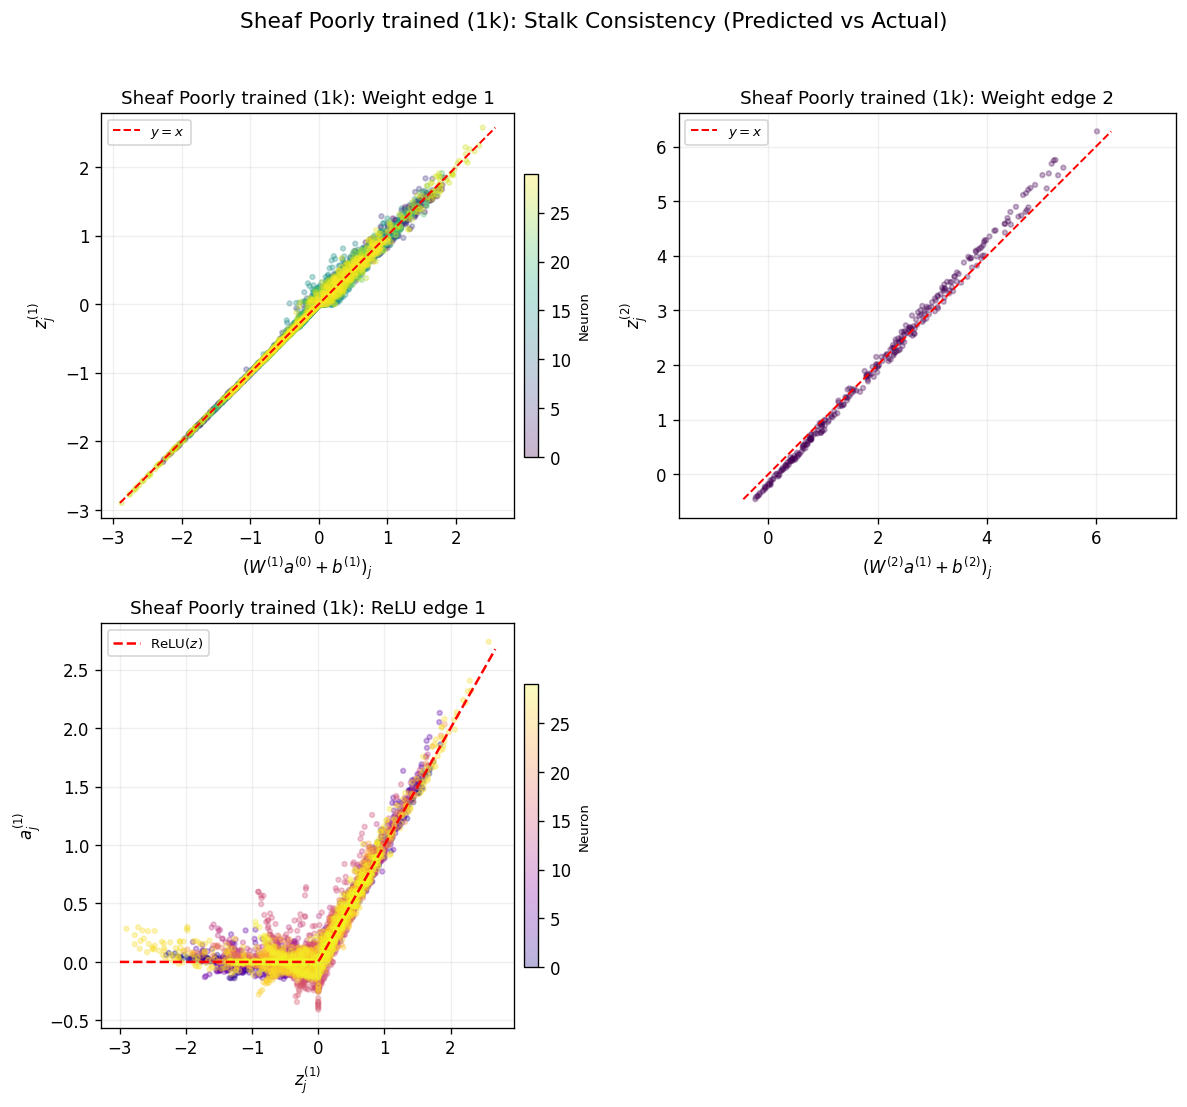

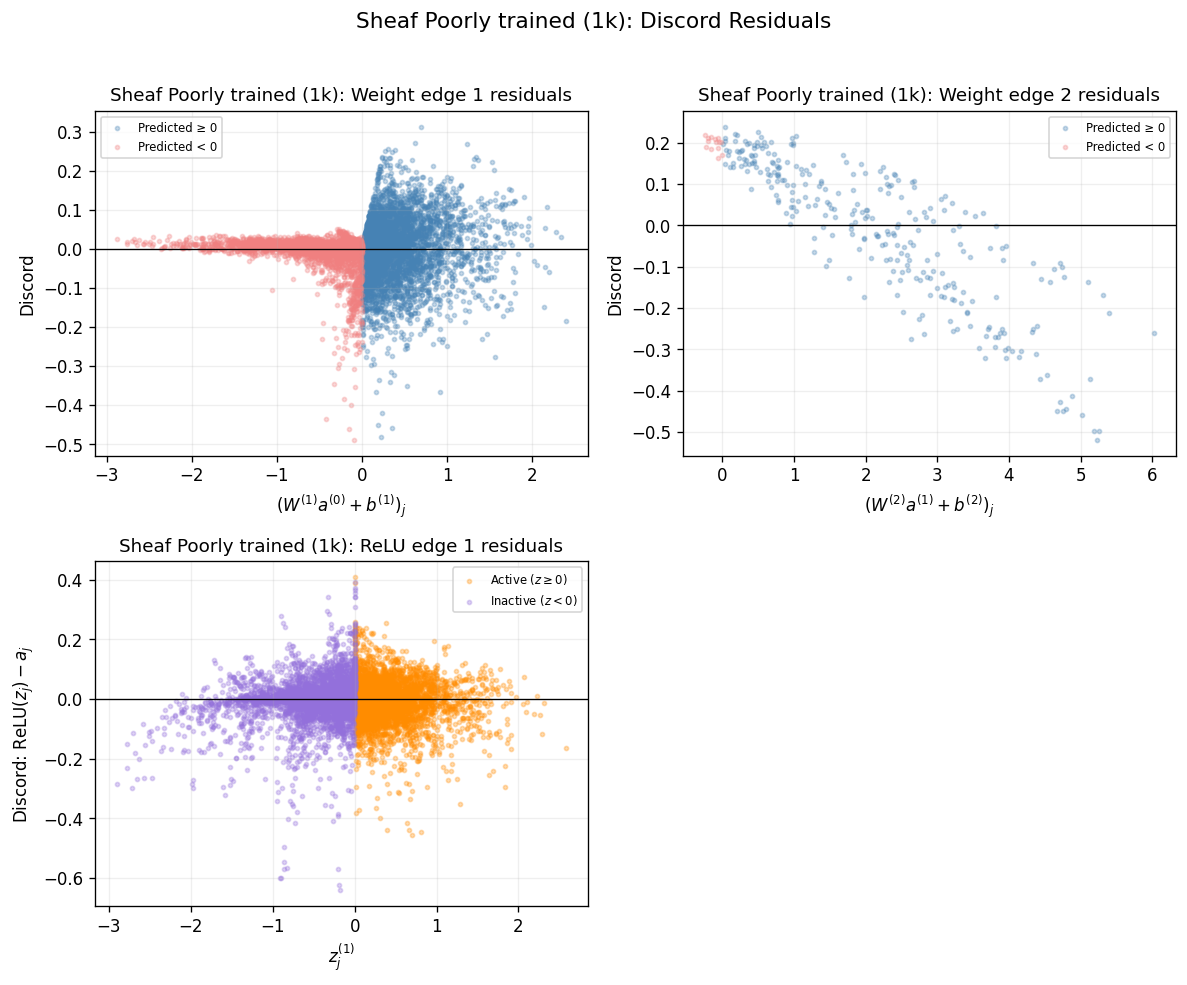

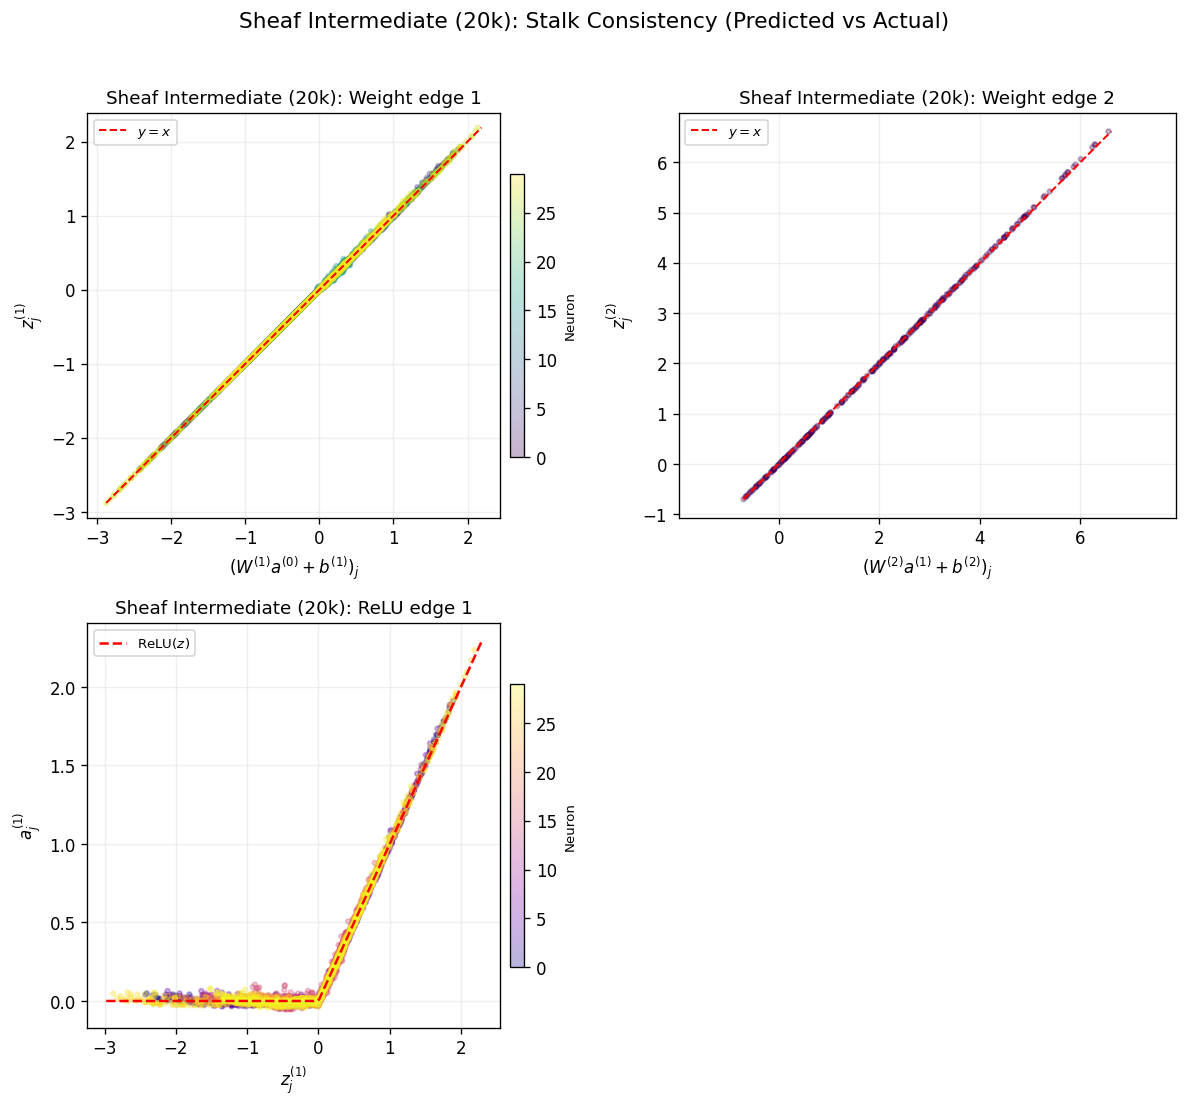

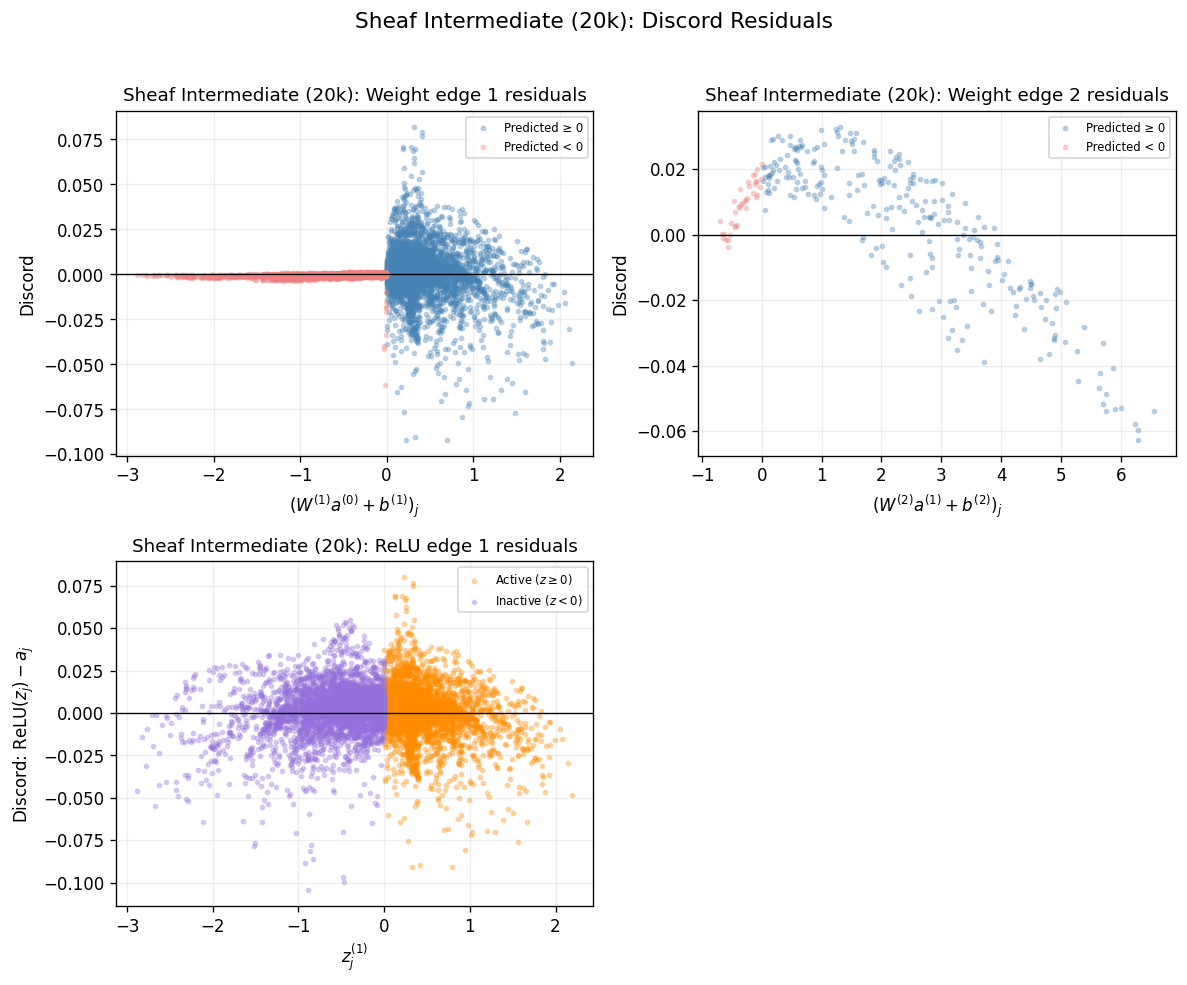

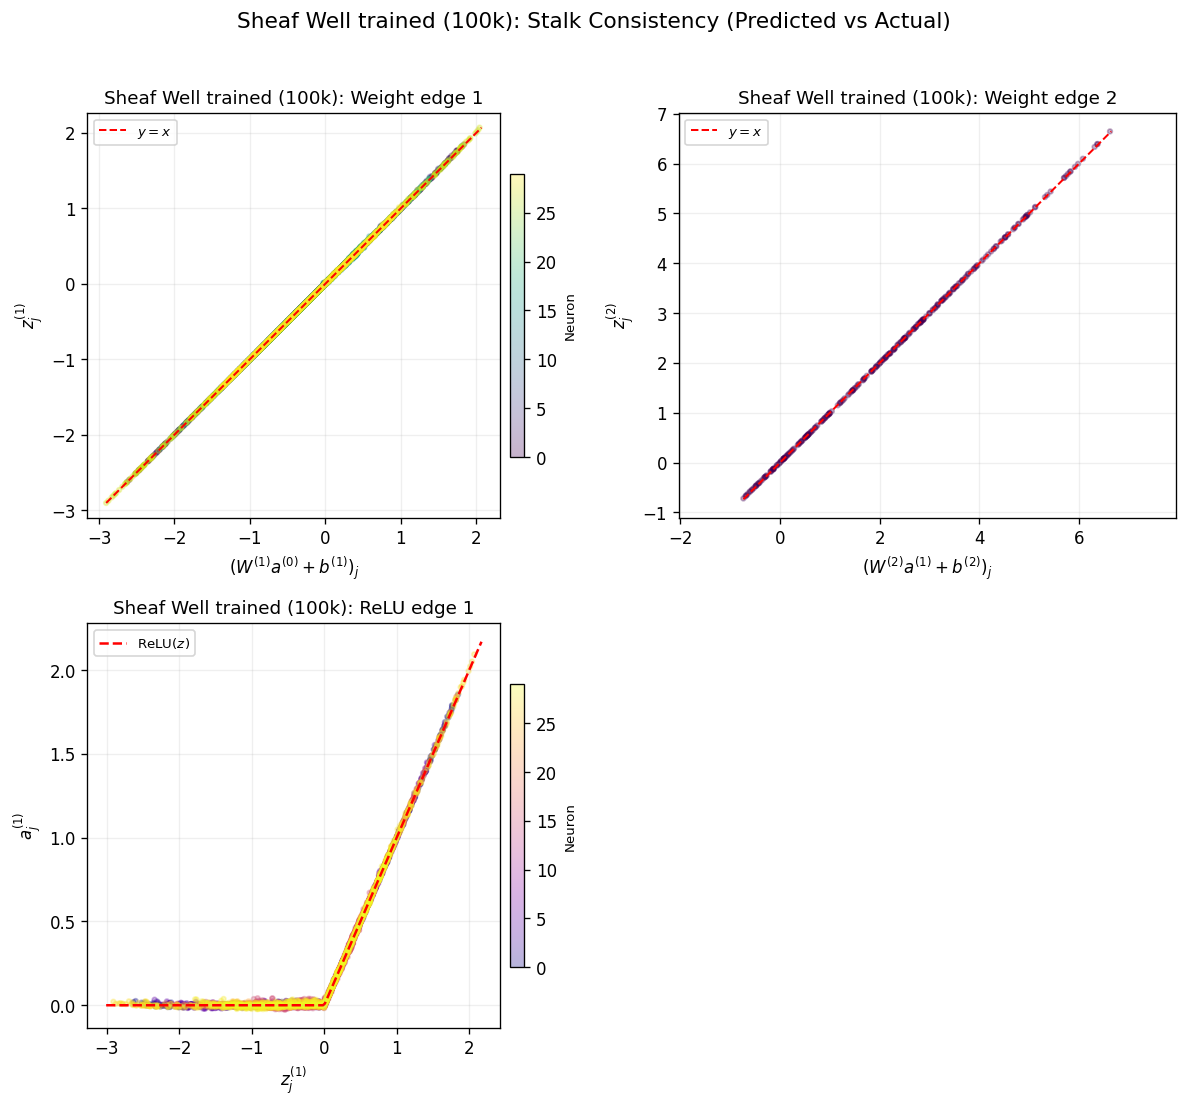

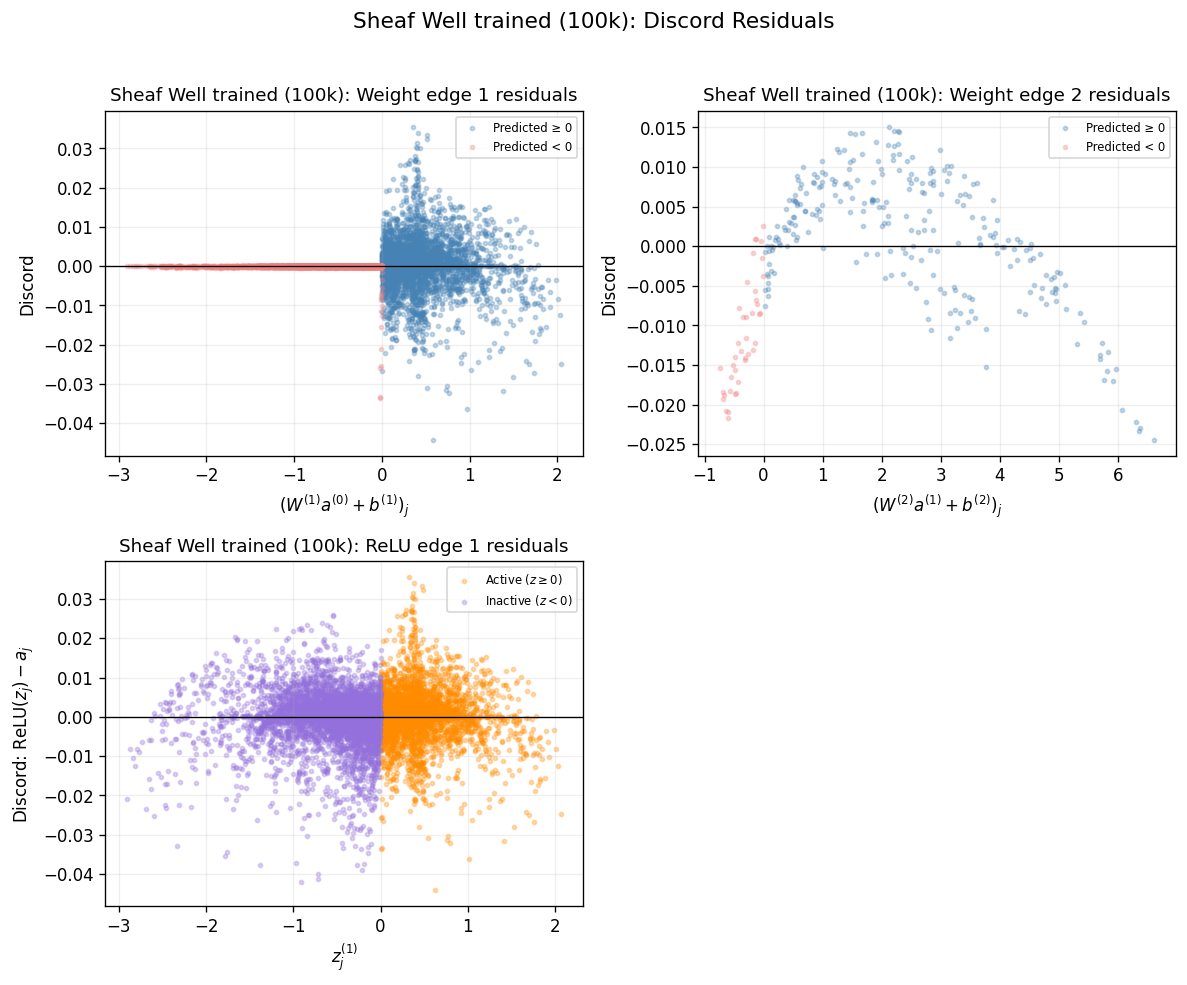

In [6]:
for (label, _, _), tag in zip(levels, level_tags):
    s_sheaf, s_state, _ = sheaf_models[tag]
    full = f"Sheaf {label} ({tag})"

    fig_pva = plot_discord_pva(s_sheaf, s_state, f'{full}: ')
    plt.show()

    fig_res = plot_discord_residuals(s_sheaf, s_state, f'{full}: ')
    plt.show()

---
## 4. SGD Discord via Pinned Diffusion

For SGD models, the forward pass satisfies all internal constraints
exactly (zero discord). To reveal error structure, we:

1. Embed the SGD weights in a NeuralSheaf
2. Initialise stalks from the forward pass (zero discord)
3. Hard-pin the output to the true labels
4. Run heat diffusion to convergence

The converged state is the harmonic extension interpolating between
the network's input and the true output. Its edge discords reveal
where in the network the prediction error propagates.

For classification (sigmoid/softmax), the output activation edge uses
identity mode to avoid saturation.

### 4a. Pinned Discord at Each Level

In [7]:
def _flatten_discord(disc_dict):
    """
    Convert compute_discord output to flat key format matching
    compute_training_discord (for use in plot_discord_summary).
    """
    flat = {'total': disc_dict['total']}
    for ell, (norm, _) in disc_dict['weight_edges'].items():
        flat[f'weight_{ell}'] = norm
    for ell, (norm, _) in disc_dict['activation_edges'].items():
        flat[f'activation_{ell}'] = norm
    if disc_dict['output_edge'] is not None:
        flat['output_edge'] = disc_dict['output_edge'][0]
    return flat

In [8]:
print("Computing SGD pinned discord at each level...")
sgd_discords_pinned = {}   # flat format for summary
sgd_pinned_states = {}     # (sheaf, state) for scatter plots

for (label, _, _), tag in zip(levels, level_tags):
    g_sheaf, g_state, g_loss = sgd_models[tag]

    gd_pinned, pinned_state, info_p = compute_pinned_discord(
        g_sheaf, X_tr, Y_tr, dt=0.01, max_iter=200_000)
    sgd_discords_pinned[tag] = _flatten_discord(gd_pinned)
    sgd_pinned_states[tag] = (g_sheaf, pinned_state)

    status = f"{info_p['iterations']} iters"
    if not info_p['converged']:
        status += " (not fully converged — increase max_iter or reduce dt)"
    print(f"  {label} ({tag}): pinned discord = {gd_pinned['total']:.6e}, "
          f"loss = {g_loss:.6f}, {status}")
    for key, val in sorted(sgd_discords_pinned[tag].items()):
        if key != 'total':
            print(f"    {key}: {val:.6e}")

Computing SGD pinned discord at each level...
  Poorly trained (1k): pinned discord = 2.413692e-02, loss = 0.138724, 200000 iters (not fully converged — increase max_iter or reduce dt)
    activation_1: 1.372044e-02
    weight_1: 6.198425e-03
    weight_2: 4.218058e-03
  Intermediate (20k): pinned discord = 7.156522e-04, loss = 0.008678, 200000 iters (not fully converged — increase max_iter or reduce dt)
    activation_1: 5.093640e-04
    weight_1: 1.463466e-04
    weight_2: 5.994156e-05
  Well trained (100k): pinned discord = 2.180958e-04, loss = 0.003293, 200000 iters (not fully converged — increase max_iter or reduce dt)
    activation_1: 1.585579e-04
    weight_1: 4.491193e-05
    weight_2: 1.462603e-05


### 4b. Predicted-vs-Actual and Residual Plots (SGD Pinned)

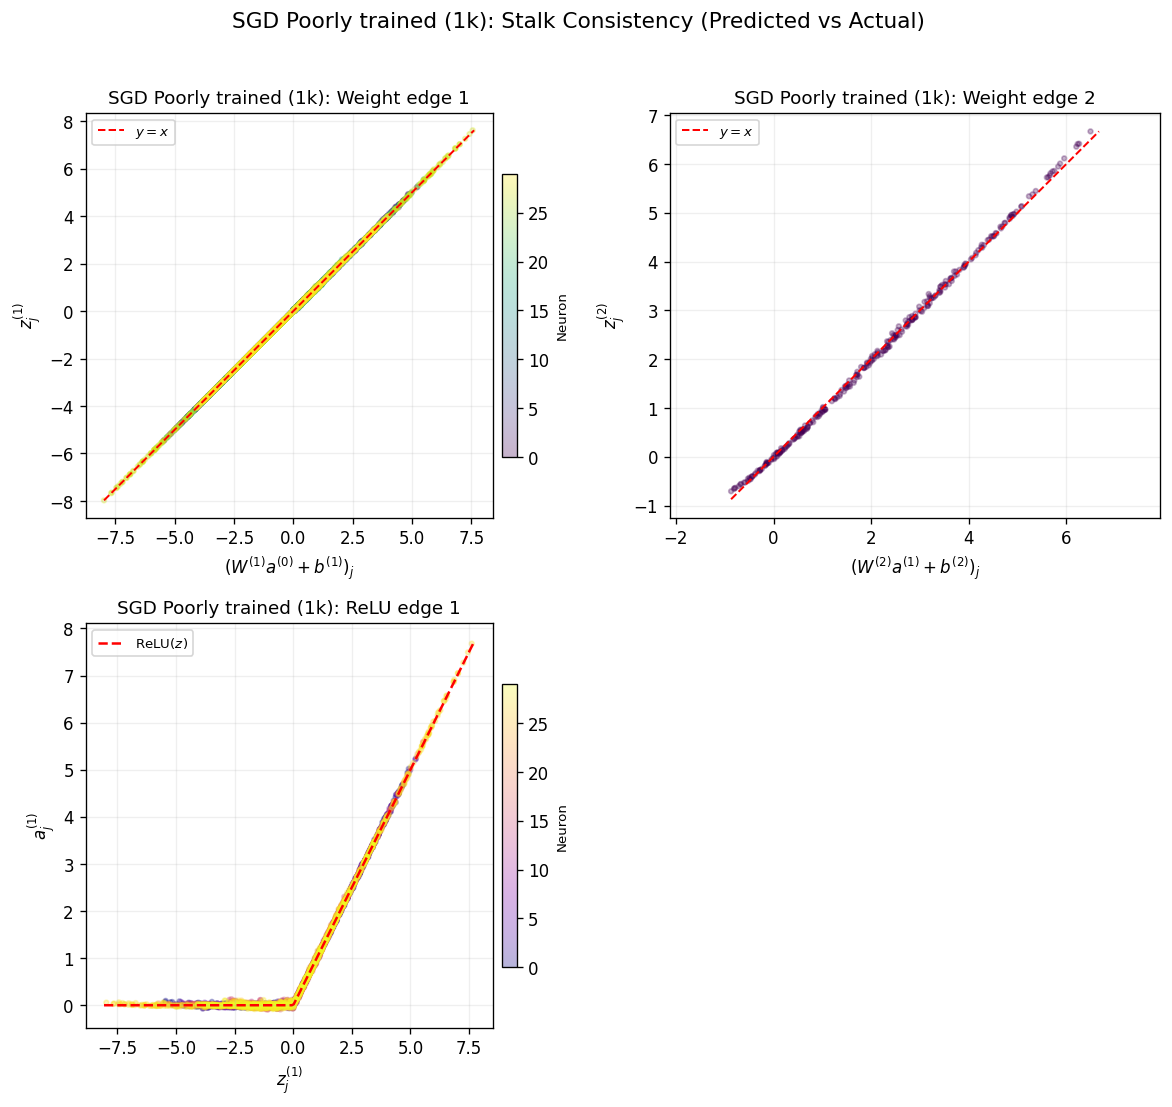

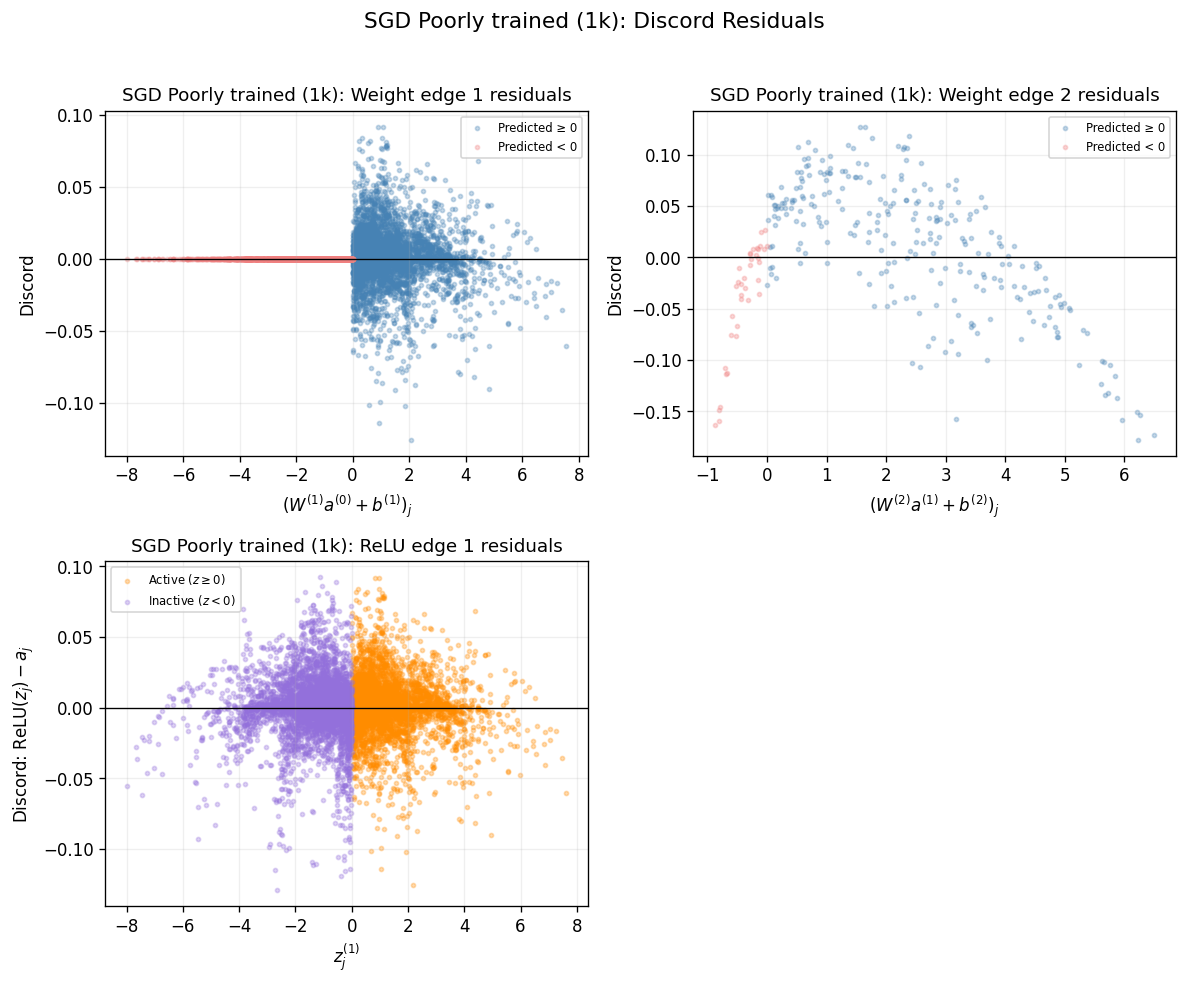

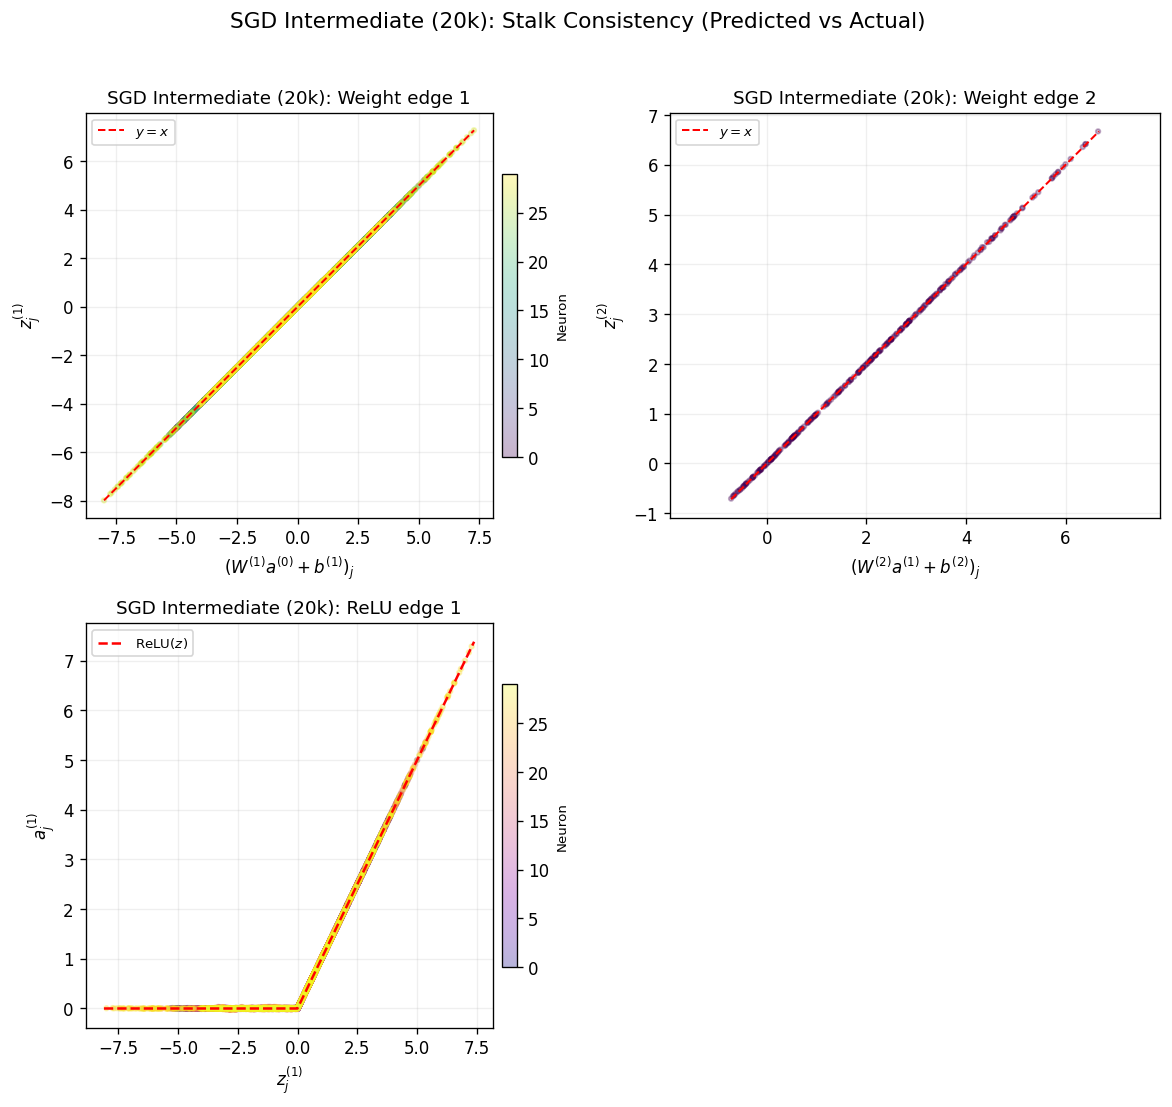

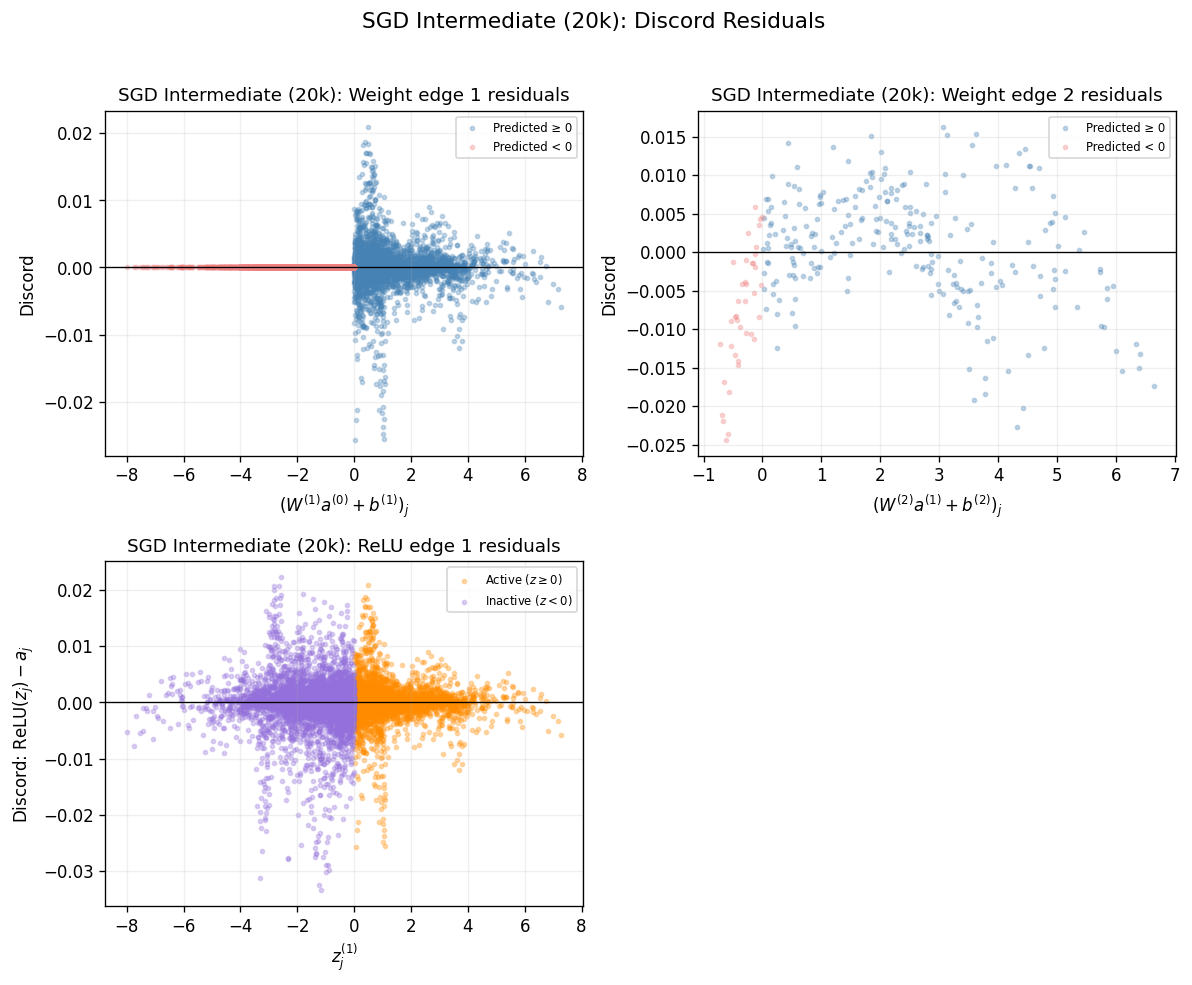

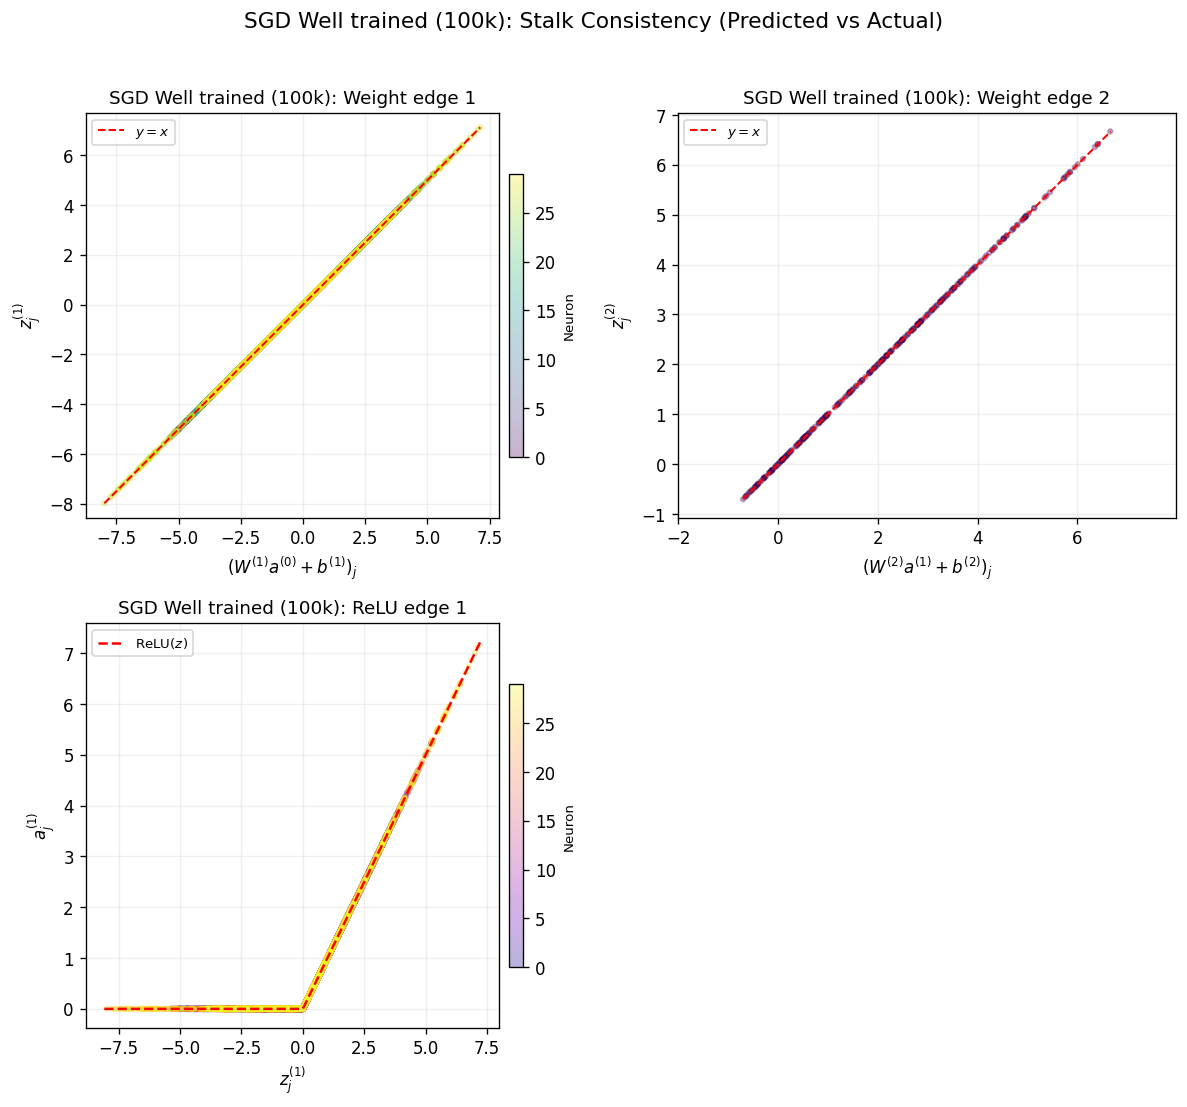

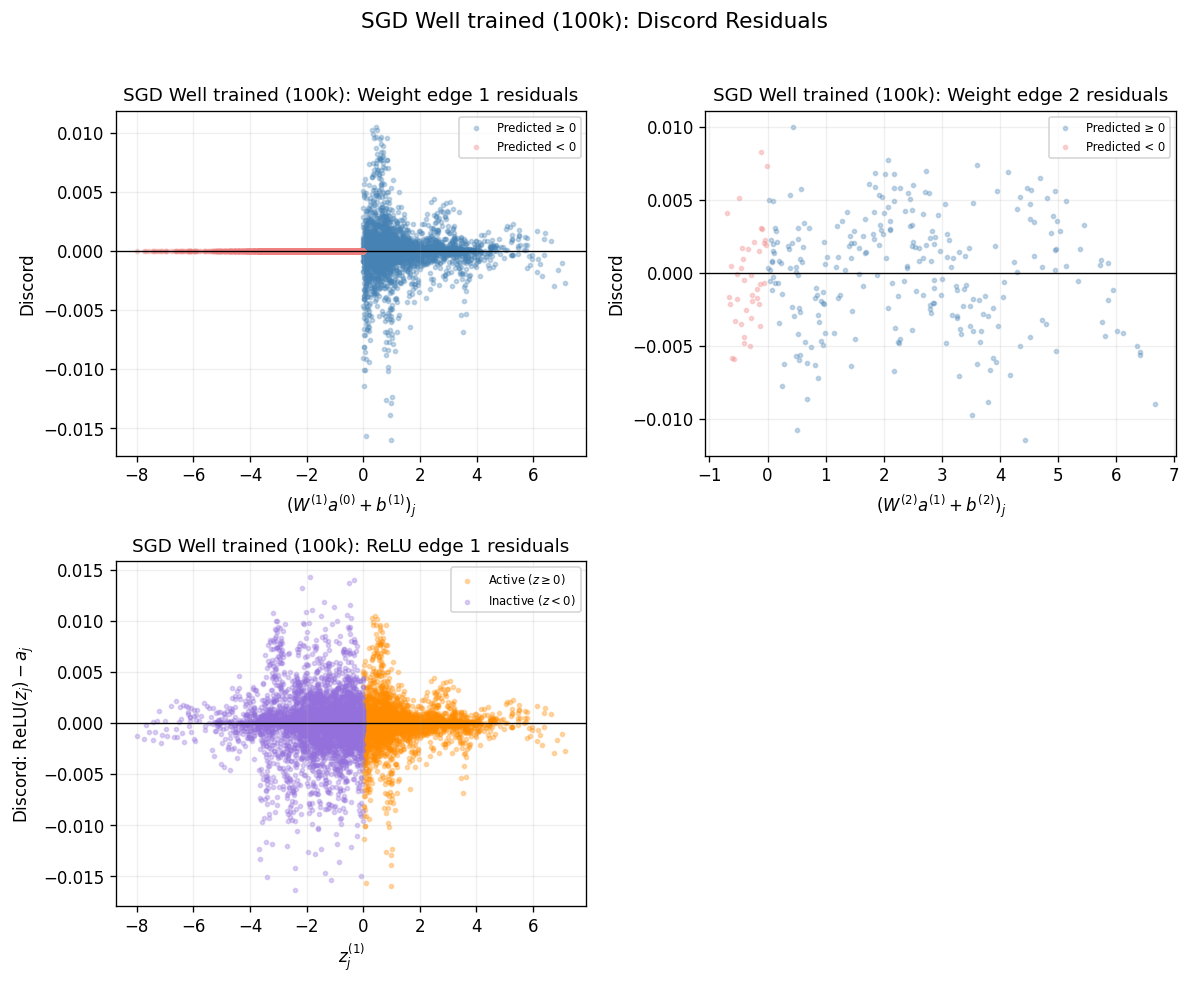

In [9]:
for (label, _, _), tag in zip(levels, level_tags):
    gp_sheaf, gp_state = sgd_pinned_states[tag]
    full = f"SGD {label} ({tag})"

    fig_pva = plot_discord_pva(gp_sheaf, gp_state, f'{full}: ')
    plt.show()

    fig_res = plot_discord_residuals(gp_sheaf, gp_state, f'{full}: ')
    plt.show()

---
## 5. Discord Summary

Four-panel comparison: loss, total internal discord, sheaf per-edge
breakdown, and SGD per-edge breakdown.

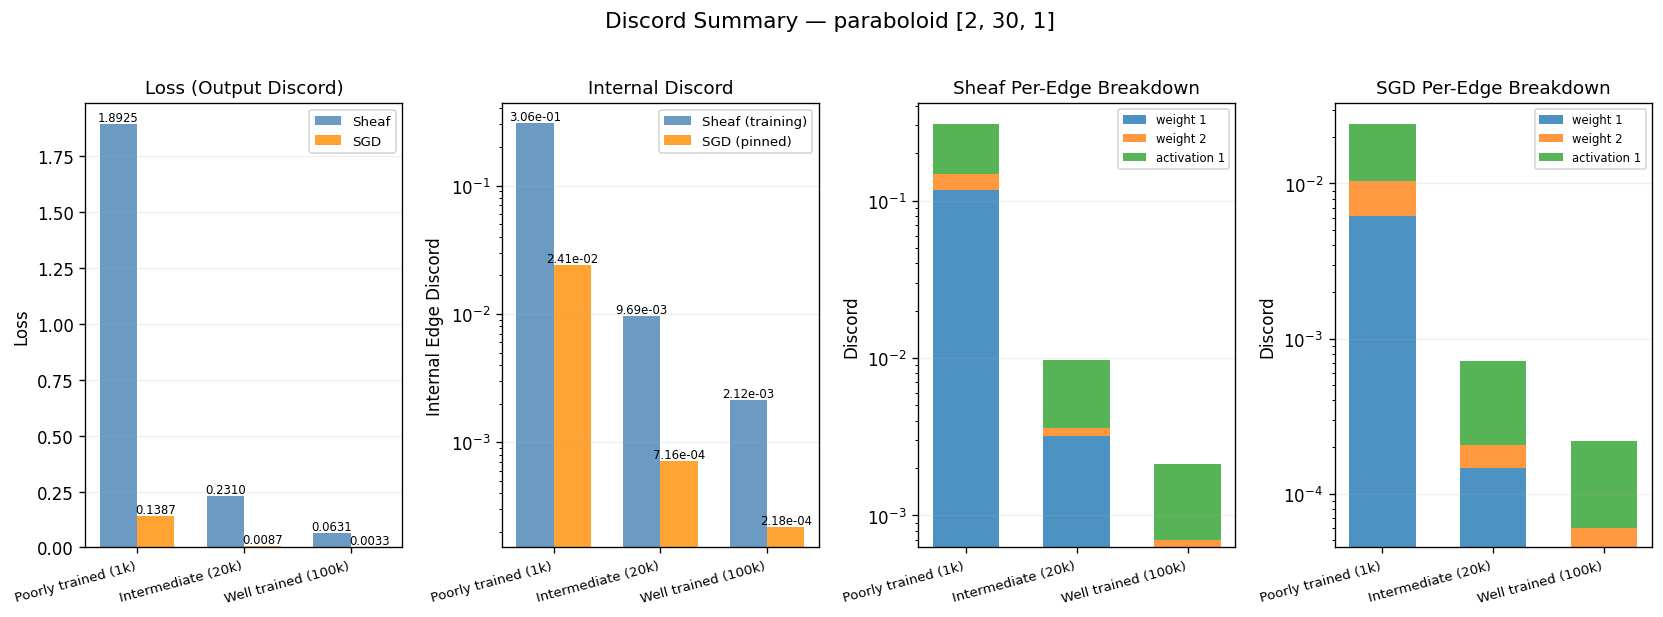

In [10]:
sheaf_summary = {}
sgd_summary = {}

for (_, _, _), tag in zip(levels, level_tags):
    _, _, s_loss = sheaf_models[tag]
    _, _, g_loss = sgd_models[tag]

    sheaf_summary[tag] = {
        **sheaf_discords[tag],
        'loss': s_loss if isinstance(s_loss, float) else s_loss,
    }
    sgd_summary[tag] = {
        **sgd_discords_pinned[tag],
        'loss': g_loss,
    }

fig_summary = plot_discord_summary(
    sheaf_summary, sgd_summary, level_labels, level_colors,
    title=f'Discord Summary — {TASK} {arch}')
plt.show()

---
## 6. Tension Correction Analysis

The sheaf training equilibrium is generally not exactly the forward-pass
fixed point. The deviation (tension) can be used to correct predictions.

Key diagnostics:

- **Mean deviation norms**: how far off each stalk is on average
- **Per-sample std / mean ratio**: how input-dependent the deviation is
  (ratio $\gg 1$ means a mean correction is a poor approximation)
- **Loss improvement**: does the corrected forward pass reduce loss?

In [11]:
if ENABLE_TENSION:
    print("Tension correction analysis (well-trained model)...")
    best_tag = level_tags[-1]
    s_sheaf, s_state, s_loss = sheaf_models[best_tag]

    deviation = compute_mean_deviation(s_sheaf, s_state, X_tr)

    print(f"\n  Mean deviation norms:")
    for ell, norm in enumerate(deviation['delta_z_norms']):
        print(f"    delta_z[{ell+1}]: {norm:.6f}")
    for ell, norm in enumerate(deviation['delta_a_norms']):
        print(f"    delta_a[{ell+1}]: {norm:.6f}")

    print(f"\n  Per-sample std (input-dependence):")
    for ell, std in enumerate(deviation['delta_z_std']):
        norm = deviation['delta_z_norms'][ell]
        ratio = std / norm if norm > 1e-12 else float('inf')
        print(f"    delta_z[{ell+1}]: std={std:.6f}  "
              f"std/mean_norm={ratio:.1f}x")
    for ell, std in enumerate(deviation['delta_a_std']):
        norm = deviation['delta_a_norms'][ell]
        ratio = std / norm if norm > 1e-12 else float('inf')
        print(f"    delta_a[{ell+1}]: std={std:.6f}  "
              f"std/mean_norm={ratio:.1f}x")

    with torch.no_grad():
        y_fwd_train, _ = s_sheaf.forward(X_tr)
        y_corr_train, _ = s_sheaf.corrected_forward(X_tr, deviation)
        y_fwd_test, _ = s_sheaf.forward(X_te)
        y_corr_test, _ = s_sheaf.corrected_forward(X_te, deviation)

        if output_activation == 'identity':
            fwd_train = mse_loss(y_fwd_train, Y_tr).item()
            corr_train = mse_loss(y_corr_train, Y_tr).item()
            fwd_test = mse_loss(y_fwd_test, Y_te).item()
            corr_test = mse_loss(y_corr_test, Y_te).item()
        else:
            fwd_train = cross_entropy_loss(y_fwd_train, Y_tr).item()
            corr_train = cross_entropy_loss(y_corr_train, Y_tr).item()
            fwd_test = cross_entropy_loss(y_fwd_test, Y_te).item()
            corr_test = cross_entropy_loss(y_corr_test, Y_te).item()

    print(f"\n  Forward-pass train loss:  {fwd_train:.6f}")
    print(f"  Corrected    train loss:  {corr_train:.6f}")
    delta_train = fwd_train - corr_train
    pct_train = delta_train / fwd_train * 100 if fwd_train > 1e-12 else 0
    print(f"  Improvement (train):      {delta_train:+.6f} ({pct_train:+.1f}%)")
    print()
    print(f"  Forward-pass test loss:   {fwd_test:.6f}")
    print(f"  Corrected    test loss:   {corr_test:.6f}")
    delta_test = fwd_test - corr_test
    pct_test = delta_test / fwd_test * 100 if fwd_test > 1e-12 else 0
    print(f"  Improvement (test):       {delta_test:+.6f} ({pct_test:+.1f}%)")
else:
    print("Tension correction analysis skipped (ENABLE_TENSION=False)")

Tension correction analysis (well-trained model)...

  Mean deviation norms:
    delta_z[1]: 0.000493
    delta_z[2]: 0.001184
    delta_a[1]: 0.000500

  Per-sample std (input-dependence):
    delta_z[1]: std=0.003607  std/mean_norm=7.3x
    delta_z[2]: std=0.242873  std/mean_norm=205.2x
    delta_a[1]: std=0.008377  std/mean_norm=16.8x

  Forward-pass train loss:  0.063092
  Corrected    train loss:  0.063054
  Improvement (train):      +0.000038 (+0.1%)

  Forward-pass test loss:   0.086497
  Corrected    test loss:   0.086414
  Improvement (test):       +0.000083 (+0.1%)


---
## 7. Interactive Plots (plotly)

Interactive predicted-vs-actual and residual scatter plots with hover
details (neuron index, sample index, discord value). Uncomment the cell
below to generate.

In [12]:
# Uncomment to generate interactive plotly plots
#
# for (label, _, _), tag in zip(levels, level_tags):
#     s_sheaf, s_state, _ = sheaf_models[tag]
#     plotly_pva(s_sheaf, s_state, f"Sheaf {label} ({tag}): ").show()
#     plotly_residuals(s_sheaf, s_state, f"Sheaf {label} ({tag}): ").show()
#
#     gp_sheaf, gp_state = sgd_pinned_states[tag]
#     plotly_pva(gp_sheaf, gp_state, f"SGD {label} ({tag}): ").show()
#     plotly_residuals(gp_sheaf, gp_state, f"SGD {label} ({tag}): ").show()

---
## Summary

| Observation | Detail |
|-------------|--------|
| **Discord on active neurons** | ReLU edges at contested boundaries carry the most discord — the activation mask is binary but the dynamics are continuous. |
| **Weight edge discord decreases** | As weights converge, restriction maps become consistent (predicted $\approx$ actual). |
| **SGD pinned discord** | Reveals how forward-pass prediction error distributes backwards through the network layers. |
| **Tension correction** | Small mean deviations for well-trained models; std/mean ratio diagnoses whether a global correction is appropriate. |

Discord and spectral analyses provide complementary views into the sheaf's
geometry. Spectral properties characterise the *global* diffusion structure
(convergence rate, stiffness, mode concentration), while discord provides
*local* edge-by-edge diagnostics of where the network is farthest from
consistency.